 # X Sentimental Analysis

# Table of Content

# 1 Overview

CrowdFlower Twitter Band Sentiment Dataset was obtained via via data.world websites, where byweets labelled by human raters as Positive, Negative, Neutral, or I can't tell.
This project used 

## 1.1  Business Understanding

Apple and Google are two of the world's most followed technology brands on social media.  X is one of the primary platforms where consumers publicly express their opinions about products, after a product launch, a software update, a price change, or a customer service experience.
Currently, product and marketing teams at these companies rely on manual review, delayed surveys, or expensive third-party tools to understand public sentiment. This is slow, costly, and does not scale.
With over 500 million tweets sent per day globally, there is an enormous amount of real-time, unsolicited customer feedback sitting in public data,largely untapped.
An automated sentiment classifier trained on real Twitter data solves this directly. It enables teams to monitor brand perception continuously, respond to negative sentiment spikes quickly, and make data-driven product decisions.

### 1.1.0 Business Problem

Since Apple and Google product teams have no scalable, automated way to monitor whether public sentiment about their products on Twitter is positive or negative in real time.

Manual monitoring is not feasible at scale. Existing tools are generic and not trained on tech brand-specific language. There is no internal model that can read a tweet and instantly classify it as a positive or negative signal — enabling the team to act on it.

Due to this, developing a neural language processing model will help the business come up with accurate public sentiments that will help in decision making.

### 1.1.1 Objectives

1. To determine whether tweet text alone can reliably predict whether the sentiment toward an Apple or Google product is positive or negative.
2. To establish which classification algorithm performs best on this dataset — a statistical model (Logistic Regression, Naive Bayes) or a neural network (Keras/TensorFlow).
3. To evaluate how TF-IDF feature engineering compares to simple Bag-of-Words (CountVectorizer) in terms of model performance.

### 1.1.2 Research Questions

1. Can tweet text alone reliably predict whether the sentiment toward an Apple or Google product is positive or negative?
2. Which classification algorithm performs best on this dataset — a statistical model (Logistic Regression, Naive Bayes) or a neural network (Keras/TensorFlow)?
3. How does TF-IDF feature engineering compare to simple Bag-of-Words (CountVectorizer) in terms of model performance?

### 1.1.3 Success Metrics


1. Achieve a Weighted F1-score ≥ 0.80 as the primary metric to account for class imbalance between Positive (84%) and Negative (16%) tweets.
2. Achieve a Recall ≥ 0.75 for the Negative class since missing a negative tweet is more costly to the business than a false alarm.
3. Achieve a ROC-AUC ≥ 0.85 to ensure the model reliably separates Positive from Negative across all thresholds.
4. Ensure Cross-validation F1 is within 0.03 of test F1 to confirm the model generalises well and is not overfitting.


## 1.2. Data Understanding

The dataset used in this project is the CrowdFlower Twitter Brand Sentiment dataset sourced from data.world. It contains 9,093 tweets collected around the SXSW conference where both Apple and Google had a significant presence. Human raters manually labelled each tweet for sentiment.

### 1.2.0 Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import squarify
import re
import warnings
warnings.filterwarnings('ignore')
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import TweetTokenizer
from nltk.stem import WordNetLemmatizer
from nltk import pos_tag, word_tokenize
nltk.download('stopwords',    quiet=True)
nltk.download('wordnet',      quiet=True)
nltk.download('omw-1.4',      quiet=True)
nltk.download('averaged_perceptron_tagger', quiet=True)
nltk.download('punkt',        quiet=True)
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             f1_score, roc_auc_score, RocCurveDisplay)
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from scipy.sparse import issparse
import shap
import lime
from lime.lime_text import LimeTextExplainer
from wordcloud import WordCloud
pd.set_option('display.max_colwidth', 120)
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 110



### 1.2.1 Loading Dataset

In [2]:
# Load the dataset using pandas
df = pd.read_csv('judge-1377884607_tweet_product_company.csv', encoding='latin-1')

### 1.2.2 Previewing Dataset

In [3]:
# checking the first few rows of my data
df.head()

,tweet_text,emotion_in_tweet_is_directed_at,is_there_an_emotion_directed_at_a_brand_or_product
0,".@wesley83 I have a 3G iPhone. After 3 hrs tweeting at #RISE_Austin, it was dead! I need to upgrade. Plugin station...",iPhone,Negative emotion
1,"@jessedee Know about @fludapp ? Awesome iPad/iPhone app that you'll likely appreciate for its design. Also, they're ...",iPad or iPhone App,Positive emotion
2,@swonderlin Can not wait for #iPad 2 also. They should sale them down at #SXSW.,iPad,Positive emotion
3,@sxsw I hope this year's festival isn't as crashy as this year's iPhone app. #sxsw,iPad or iPhone App,Negative emotion
4,"@sxtxstate great stuff on Fri #SXSW: Marissa Mayer (Google), Tim O'Reilly (tech books/conferences) &amp; Matt Mullen...",Google,Positive emotion


In [4]:
# checking columns and rows
df.shape

(9093, 3)

In [5]:
#checking data type
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9093 entries, 0 to 9092
Data columns (total 3 columns):
 #   Column                                              Non-Null Count  Dtype 
---  ------                                              --------------  ----- 
 0   tweet_text                                          9092 non-null   object
 1   emotion_in_tweet_is_directed_at                     3291 non-null   object
 2   is_there_an_emotion_directed_at_a_brand_or_product  9093 non-null   object
dtypes: object(3)
memory usage: 213.2+ KB


# NOTE:
 The dataset contains 9,093 rows and 3 text columns, with 1 missing tweet in tweettext and 5,802 missing values in emotionintweetisdirectedat since many tweets …The dataset contains 9,093 rows and 3 text columns, with 1 missing tweet in tweet_text and 5,802 missing values in emotion_in_tweet_is_directed_at since many tweets are not directed at a specific product. The target column is_there_an_emotion_directed_at_a_brand_or_product has no missing values, and all columns are object dtype meaning all features must be engineered from raw text using NLP techniques.

In [6]:
# Describing our Data
df.describe(include='all')

,tweet_text,emotion_in_tweet_is_directed_at,is_there_an_emotion_directed_at_a_brand_or_product
count,9092,3291,9093
unique,9065,9,4
top,RT @mention Marissa Mayer: Google Will Connect the Digital &amp; Physical Worlds Through Mobile - {link} #sxsw,iPad,No emotion toward brand or product
freq,5,946,5389


In [7]:
# checking for Duplicates
duplicates = df.duplicated().sum()
print(f'Number of duplicate rows: {duplicates}')

Number of duplicate rows: 22


### 1.2.3 Data Preparation

In this section, we prepare the dataset for modelling by dropping missing values, filtering to only positive and negative tweets, encoding the target labels, and cleaning the raw tweet text using NLTK preprocessing techniques including tokenization, stopword removal and lemmatization.

### 1.2.3.1 Renaming Columns

In [8]:
df.columns = ['tweet', 'product', 'sentiment']
print(df.columns.tolist())

['tweet', 'product', 'sentiment']


### 1.2.3.2 Dropping Missing tweets

In [9]:
df.dropna(subset=['tweet'], inplace=True)
print(f'Shape after dropping missing tweet: {df.shape}')

Shape after dropping missing tweet: (9092, 3)


In [10]:
#confriming if we have any missing tweets
df.isnull().sum()

tweet           0
product      5801
sentiment       0
dtype: int64

## Note: no missing tweets

### 1.2.3.2 Filtering positive and Negative

In [11]:
binary_df = df[df['sentiment'].isin(['Positive emotion', 'Negative emotion'])].copy()
binary_df.reset_index(drop=True, inplace=True)

print(f'Binary dataset shape: {binary_df.shape}')
print('\nClass distribution:')
print(binary_df['sentiment'].value_counts())

Binary dataset shape: (3548, 3)

Class distribution:
sentiment
Positive emotion    2978
Negative emotion     570
Name: count, dtype: int64


### 1.2.3.3 Hot-encoding our Data

Making Negative and Positve in binary form

In [12]:
binary_df['label'] = (binary_df['sentiment'] == 'Positive emotion').astype(int)

print('Label encoding: Positive emotion = 1  |  Negative emotion = 0')
print(binary_df['label'].value_counts().rename({1:'Positive (1)', 0:'Negative (0)'}))

Label encoding: Positive emotion = 1  |  Negative emotion = 0
label
Positive (1)    2978
Negative (0)     570
Name: count, dtype: int64


### 1.2.3.4 Text Preprocessing Data

In [13]:
tokenizer  = TweetTokenizer(preserve_case=False, strip_handles=True, reduce_len=True)
lemmatizer = WordNetLemmatizer()
STOP_WORDS = set(stopwords.words('english'))
STOP_WORDS.update(['sxsw', 'mention', 'rt', 'amp', 'via', 'http', 'co', 'ht'])

def preprocess(text):
    text = str(text).lower()                          
    text = re.sub(r'http\S+|www\S+', '', text)        
    text = re.sub(r'@\w+', '', text)                  
    text = re.sub(r'&\w+;', '', text)                 
    text = re.sub(r'#', '', text)                     
    text = re.sub(r'\d+', '', text)                   
    text = re.sub(r'[^\w\s]', '', text)               

    tokens = tokenizer.tokenize(text)
    tokens = [t for t in tokens if t not in STOP_WORDS and len(t) > 2]
    tokens = [lemmatizer.lemmatize(t) for t in tokens]

    return ' '.join(tokens)


### 1.2.3.5 Pre-processing data

In [14]:
binary_df['clean_tweet'] = binary_df['tweet'].apply(preprocess)

# Preview
binary_df[['tweet', 'clean_tweet', 'label']].sample(5, random_state=42)

,tweet,clean_tweet,label
299,New Post: iPad 2 Launches to Huge Lines at Apple Pop-Up Shop in Austin {link} #SXSW #SXSWi,new post ipad launch huge line apple popup shop austin link sxswi,1
2550,"RT @mention NYT app for iPad: not &quot;here's an amazing way to serve our readership,&quot; more &quot;here's a mar...",nyt app ipad here amazing way serve readership here market opportunity cant ignore newsapps,1
3080,Steve Jobs doesn't position the iPhone as a device made in China where suicide rates are high He sells dreams #Kawas...,steve job doesnt position iphone device made china suicide rate high sell dream kawasaki thisisdare,0
2342,RT @mention Google Circles will be toast if it can't convince facebook users to start an account (or interface with ...,google circle toast cant convince facebook user start account interface,0
1211,Thanks @mention for giving me new top cover for my banged up juicepack iphone case. You and your products rock! #tra...,thanks giving new top cover banged juicepack iphone case product rock tradeshow,1


In [15]:
# Confirming if data is cleaned
print(f'Total tweets for modelling: {binary_df.shape[0]}')
print(f'Missing values: {binary_df["clean_tweet"].isnull().sum()}')
print(f'Empty strings: {(binary_df["clean_tweet"] == "").sum()}')

Total tweets for modelling: 3548
Missing values: 0
Empty strings: 0


### 1.2.4 Exploratary Data Analysis

In this section, we explore the dataset visually and statistically to understand the distribution of sentiment classes, the most common words, tweet length patterns, and language structure across Apple and Google products before modelling.Both Univeriate and  Bivariate Analysis were used.

# a) Univariate Analysis

In this section, we analyse each variable individually to understand the distribution of sentiment classes, tweet lengths and the most frequently used words across the dataset before exploring relationships between variables.

## Research Q1:Can tweet text alone reliably predict whether the sentiment toward an Apple or Google product is positive or negative?

## Sentiment class distribution

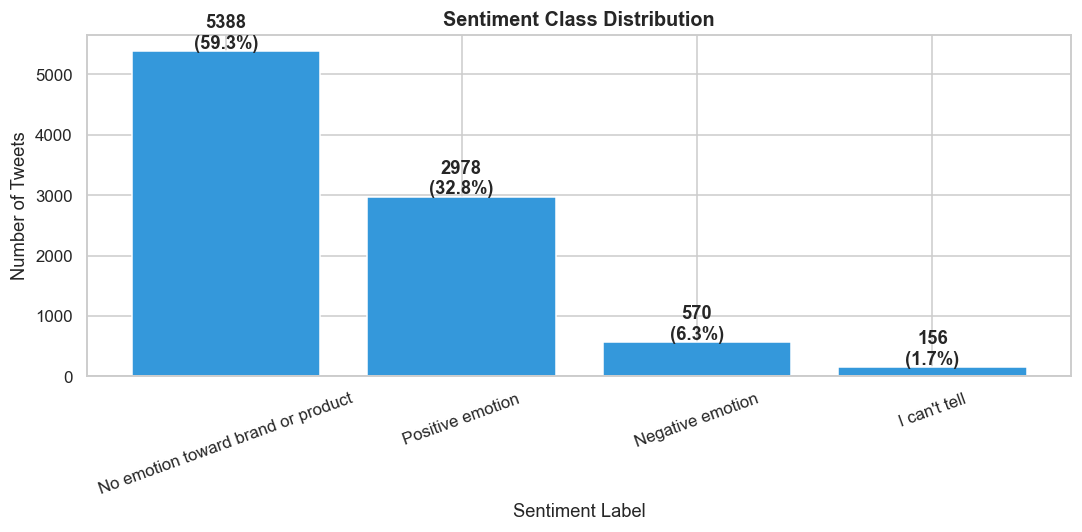

In [16]:
plt.figure(figsize=(10, 5))
sent_counts = df['sentiment'].value_counts()
total = len(df)

plt.bar(sent_counts.index, sent_counts.values, color='#3498db', edgecolor='white')
plt.title('Sentiment Class Distribution', fontsize=13, fontweight='bold')
plt.xlabel('Sentiment Label')
plt.ylabel('Number of Tweets')
plt.xticks(rotation=20)
for i, v in enumerate(sent_counts.values):
    plt.text(i, v + 40, f'{v}\n({v/total*100:.1f}%)', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

# Note:
The distribution reveals a heavily imbalanced dataset where 59.3% of tweets carry no emotion toward any brand or product, 32.7% are positive, 6.3% are negative and only 1.7% are labelled as uncertain. This confirms that predicting sentiment from text alone is a challenge, for binary classification we will retain only the 2,978 positive and 570 negative tweets, and apply class_weight='balanced' in all models to prevent the classifier from ignoring the minority negative class.

# Word clouds

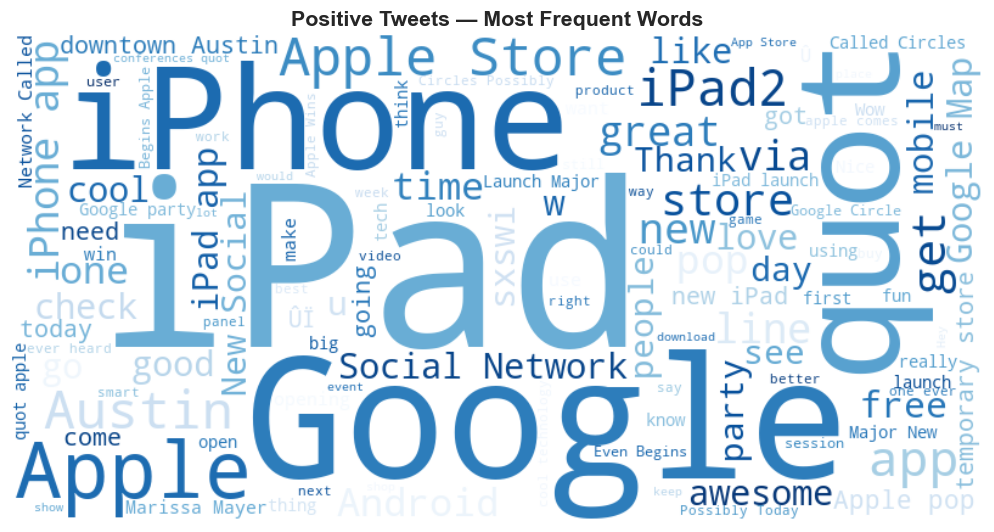

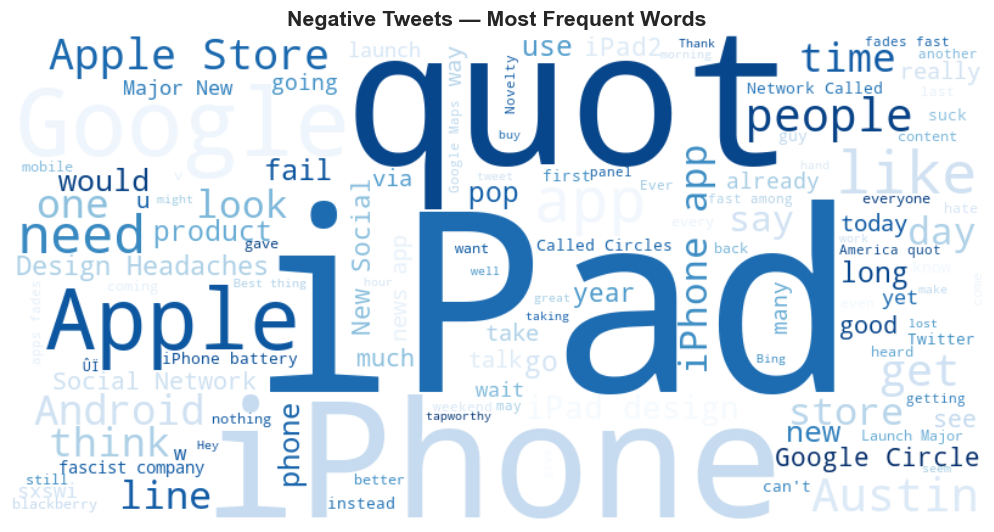

In [17]:
STOP = set(stopwords.words('english'))
STOP.update(['http','https','rt','amp','co','mention','sxsw','link','ht','ly','bit'])

def make_wordcloud(texts, title, colormap):
    combined = ' '.join(str(t) for t in texts)
    combined = re.sub(r'http\S+|@\S+', '', combined)
    wc = WordCloud(
        width=800, height=400, background_color='white',
        stopwords=STOP, colormap=colormap, max_words=120
    ).generate(combined)
    plt.figure(figsize=(11, 5))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

make_wordcloud(
    binary_df[binary_df['sentiment'] == 'Positive emotion']['tweet'],
    'Positive Tweets — Most Frequent Words', 'Blues'
)
make_wordcloud(
    binary_df[binary_df['sentiment'] == 'Negative emotion']['tweet'],
    'Negative Tweets — Most Frequent Words', 'Blues'
)

# NOTE:
The word clouds reveal a clear vocabulary separation between positive and negative tweets. Positive tweets are dominated by words like love, great, new, free and awesome while negative tweets contain words like fail, crash, bad and broken. This distinct difference in vocabulary between the two classes is strong visual evidence that tweet text alone contains enough signal to predict sentiment — confirming that a text-based classifier is a viable approach for this problem.

# b) Bivariate Analysis

In this section, we analyse the relationship between two variables at a time to understand how sentiment interacts with product, tweet length and language structure across the dataset.

## Research Q2:2. Which classification algorithm performs best on this dataset — a statistical model (Logistic Regression, Naive Bayes) or a neural network (Keras/TensorFlow)?

# Sentiment by Product Heatmap

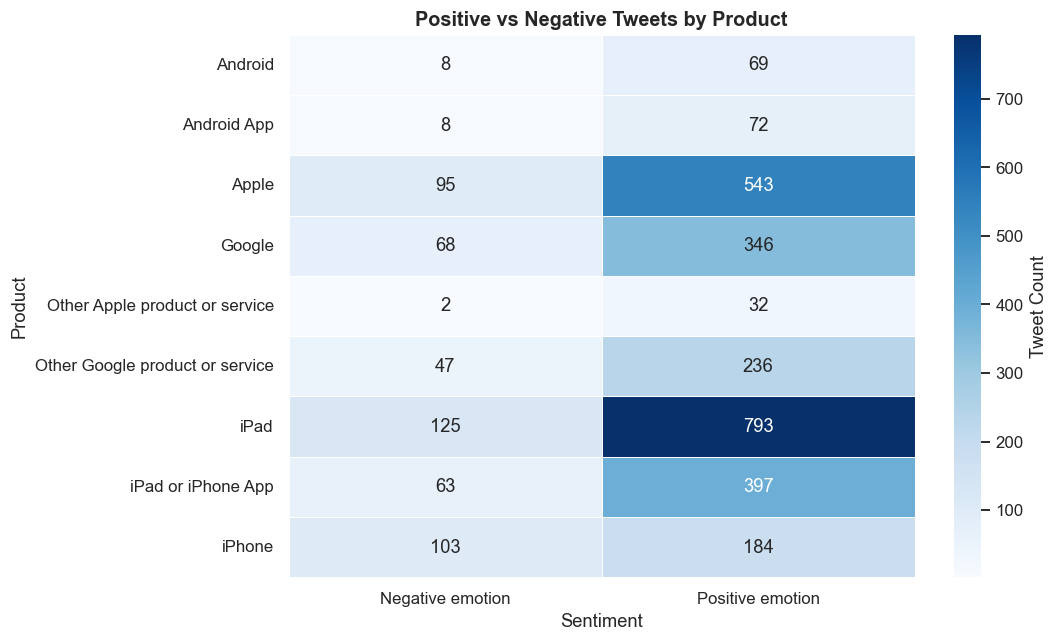

In [18]:
pos_neg = df[df['sentiment'].isin(['Positive emotion', 'Negative emotion'])].dropna(subset=['product'])
pivot = pos_neg.groupby(['product', 'sentiment']).size().unstack(fill_value=0)

plt.figure(figsize=(10, 6))
sns.heatmap(pivot, annot=True, fmt='d', cmap='Blues',
            linewidths=0.5, linecolor='white',
            cbar_kws={'label': 'Tweet Count'})
plt.title('Positive vs Negative Tweets by Product', fontsize=13, fontweight='bold')
plt.xlabel('Sentiment')
plt.ylabel('Product')
plt.tight_layout()
plt.show()

# Note:
The heatmap reveals that iPad dominates positive mentions with 793 tweets, followed by Apple with 543 and Google with 346, while iPhone has the highest negative emotion relative to its positive tweets with 103 negative out of 287 total. Android and Android App have the fewest tweets overall, suggesting limited representation in the dataset. The clear difference in intensity between positive and negative columns across all products confirms that product-specific language patterns exist in the text, supporting the case that a classifier can learn to distinguish sentiment from tweet content alone.

## Research Question 3 :How does TF-IDF feature engineering compare to simple Bag-of-Words (CountVectorizer) in terms of model performance?

# Tweet length vs sentiment



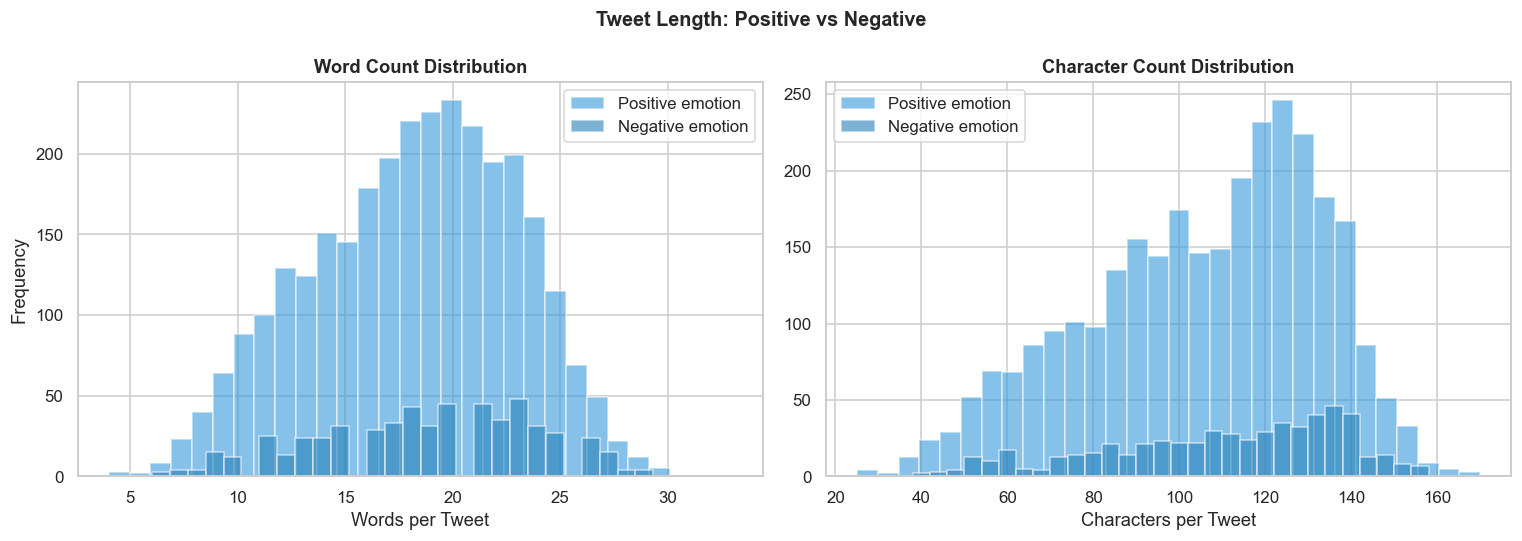

                 word_count                                            \
                      count   mean   std  min   25%   50%   75%   max   
sentiment                                                               
Negative emotion      570.0  18.76  5.08  6.0  15.0  19.0  23.0  31.0   
Positive emotion     2978.0  18.18  4.94  4.0  15.0  19.0  22.0  33.0   

                 char_count                                                  
                      count    mean    std   min   25%    50%    75%    max  
sentiment                                                                    
Negative emotion      570.0  109.45  27.39  38.0  91.0  114.0  132.0  158.0  
Positive emotion     2978.0  105.56  27.13  25.0  86.0  110.0  127.0  170.0  


In [19]:
binary_df['word_count'] = binary_df['tweet'].astype(str).apply(lambda x: len(x.split()))
binary_df['char_count'] = binary_df['tweet'].astype(str).apply(len)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for label, color in [('Positive emotion', '#3498db'), ('Negative emotion', '#2980b9')]:
    subset = binary_df[binary_df['sentiment'] == label]
    axes[0].hist(subset['word_count'], bins=30, alpha=0.6, label=label, color=color)
    axes[1].hist(subset['char_count'], bins=30, alpha=0.6, label=label, color=color)

axes[0].set_title('Word Count Distribution', fontweight='bold')
axes[0].set_xlabel('Words per Tweet')
axes[0].set_ylabel('Frequency')
axes[0].legend()
axes[1].set_title('Character Count Distribution', fontweight='bold')
axes[1].set_xlabel('Characters per Tweet')
axes[1].legend()
plt.suptitle('Tweet Length: Positive vs Negative', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(binary_df.groupby('sentiment')[['word_count','char_count']].describe().round(2))

# Note:
Negative tweets have a slightly higher mean word count (18.76) and character count (109.45) compared to positive tweets (18.18 words, 105.56 characters), suggesting that users tend to write slightly longer tweets when expressing negative sentiment. Both classes have similar standard deviations meaning tweet lengths are fairly consistent across the dataset. The overlap in distributions confirms that tweet length alone is not a strong distinguishing feature — the model must rely on the actual words used, making TF-IDF a stronger feature engineering choice than Bag-of-Words since it weights unique sentiment-bearing words more heavily than common ones.

## Research Q3: Additional graph Analysis

 # POS tag spider chart

In [20]:
from nltk import pos_tag, word_tokenize

pos_neg_df = binary_df.dropna(subset=['tweet'])

def get_pos_tags(text):
    tokens = word_tokenize(str(text).lower())
    tags = pos_tag(tokens)
    return [tag for _, tag in tags]

pos_tags = []
neg_tags = []

for _, row in pos_neg_df.iterrows():
    tags = get_pos_tags(row['tweet'])
    if row['sentiment'] == 'Positive emotion':
        pos_tags.extend(tags)
    else:
        neg_tags.extend(tags)

pos_tag_counts = pd.Series(pos_tags).value_counts().head(10)
neg_tag_counts = pd.Series(neg_tags).value_counts().head(10)

print('✅ POS tags computed')

✅ POS tags computed


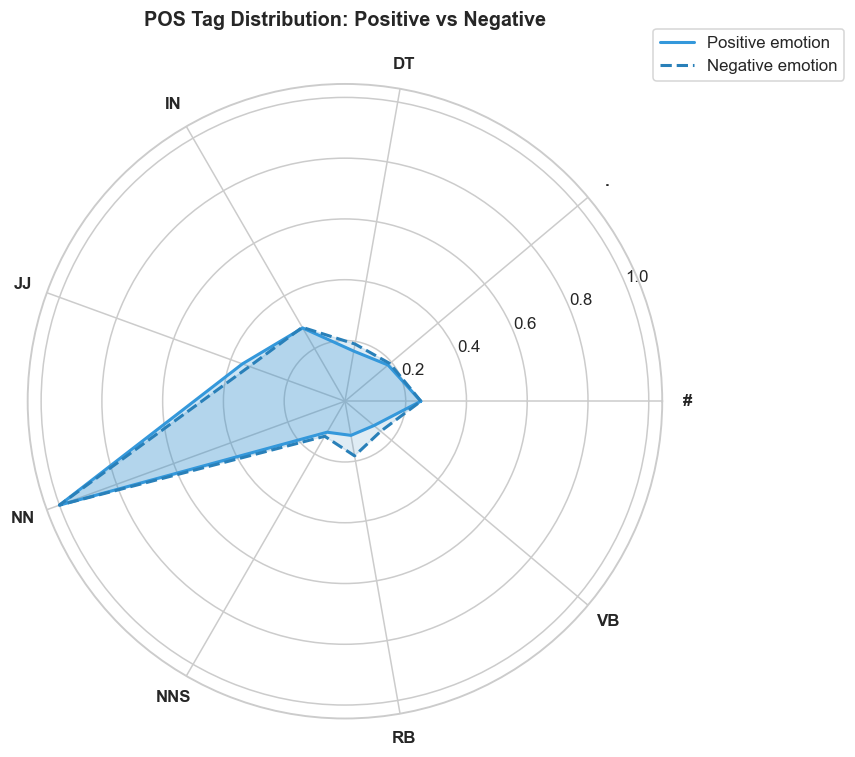

In [21]:
top_tags = list(set(pos_tag_counts.head(8).index) | set(neg_tag_counts.head(8).index))
top_tags = sorted(top_tags)

pos_values = [pos_tag_counts.get(tag, 0) for tag in top_tags]
neg_values = [neg_tag_counts.get(tag, 0) for tag in top_tags]

pos_values_norm = [v / max(pos_values) for v in pos_values]
neg_values_norm = [v / max(neg_values) for v in neg_values]

N      = len(top_tags)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()

pos_values_norm += pos_values_norm[:1]
neg_values_norm += neg_values_norm[:1]
angles          += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

ax.plot(angles, pos_values_norm, color='#3498db', linewidth=2, label='Positive emotion')
ax.fill(angles, pos_values_norm, color='#3498db', alpha=0.25)

ax.plot(angles, neg_values_norm, color='#2980b9', linewidth=2, linestyle='dashed', label='Negative emotion')
ax.fill(angles, neg_values_norm, color='#2980b9', alpha=0.15)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(top_tags, fontsize=11, fontweight='bold')
ax.set_title('POS Tag Distribution: Positive vs Negative',
             fontsize=13, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))

plt.tight_layout()
plt.show()

## NOTE:
The POS tag distribution shows that both positive and negative tweets are dominated by nouns (NN) and adjectives (JJ). Since Bag-of-Words treats all words equally, common nouns like "iPhone" and "iPad" will dominate the feature space. TF-IDF however will downweight these frequently appearing words and upweight unique sentiment-bearing adjectives like "amazing" or "broken" — making TF-IDF a more suitable feature engineering approach for this dataset. This will be confirmed in the modelling section.

# 2. Advance Modelling

In this section, we build and evaluate multiple classification models to determine which algorithm best predicts sentiment from tweet text. We begin by splitting the data, engineering text features using Bag-of-Words and TF-IDF vectorization, then train and compare models from multiple packages including scikit-learn and Keras/TensorFlow, before tuning the best model and interpreting its predictions using SHAP and LIME.

## 2.1 Spliting Data

In [22]:
X = binary_df['clean_tweet']
y = binary_df['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## 2.2 Transforming Data

In [23]:
# Bag of Words (CountVectorizer)
bow_vectorizer = CountVectorizer(ngram_range=(1, 2), max_features=10000)
X_train_bow = bow_vectorizer.fit_transform(X_train)
X_test_bow  = bow_vectorizer.transform(X_test)

In [24]:
# TF-IDF Vectorizer
tfidf_vectorizer = TfidfVectorizer(ngram_range=(1, 2), max_features=15000, sublinear_tf=True)
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf  = tfidf_vectorizer.transform(X_test)

In [25]:
print('Feature Engineering Summary')
print('='*45)
print(f'Bag of Words features  : {X_train_bow.shape[1]:,}')
print(f'TF-IDF features        : {X_train_tfidf.shape[1]:,}')
print(f'Training samples       : {X_train_bow.shape[0]:,}')
print(f'Test samples           : {X_test_bow.shape[0]:,}')

Feature Engineering Summary
Bag of Words features  : 10,000
TF-IDF features        : 15,000
Training samples       : 2,838
Test samples           : 710


# Note:
The Bag-of-Words vectorizer generated 10,000 features while TF-IDF generated 15,000 features from the clean tweet text. The training set contains 2,838 tweets and the test set contains 710 tweets, maintaining the 80/20 stratified split. TF-IDF generates more features because it captures unique word weightings across the corpus in addition to the raw word counts captured by Bag-of-Words.

# 2.3 Instantiating Models

In this section we train and compare 4 classifiers using both Bag-of-Words and TF-IDF features to determine which combination performs best.

### 2.3.1 Logistic Regression (TF-IDF)

In [26]:
lr_model = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
lr_model.fit(X_train_tfidf, y_train)
y_pred_lr = lr_model.predict(X_test_tfidf)

print('=== Logistic Regression (TF-IDF) ===')
print(classification_report(y_test, y_pred_lr,
      target_names=['Negative (0)', 'Positive (1)']))
print(f'Weighted F1: {f1_score(y_test, y_pred_lr, average="weighted"):.4f}')

=== Logistic Regression (TF-IDF) ===
              precision    recall  f1-score   support

Negative (0)       0.50      0.58      0.54       115
Positive (1)       0.92      0.89      0.90       595

    accuracy                           0.84       710
   macro avg       0.71      0.74      0.72       710
weighted avg       0.85      0.84      0.84       710

Weighted F1: 0.8440


# NOTE:
Logistic Regression with TF-IDF achieves a weighted F1 score of 0.8440 and an overall accuracy of 84%, exceeding our success metric of 0.80. The model performs strongly on the positive class with a precision of 0.92 and recall of 0.89.

### 2.3.2 Random-Forest (TF-IDF)

In [27]:
rf_model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf_model.fit(X_train_tfidf, y_train)
y_pred_rf = rf_model.predict(X_test_tfidf)

print('=== Random Forest (TF-IDF) ===')
print(classification_report(y_test, y_pred_rf,
      target_names=['Negative (0)', 'Positive (1)']))
print(f'Weighted F1: {f1_score(y_test, y_pred_rf, average="weighted"):.4f}')

=== Random Forest (TF-IDF) ===
              precision    recall  f1-score   support

Negative (0)       0.86      0.31      0.46       115
Positive (1)       0.88      0.99      0.93       595

    accuracy                           0.88       710
   macro avg       0.87      0.65      0.70       710
weighted avg       0.88      0.88      0.86       710

Weighted F1: 0.8559


# Note:
Random Forest with TF-IDF achieves the highest weighted F1 score of 0.8559 and an overall accuracy of 88%, exceeding our success metric of 0.80. However despite its strong overall performance, the model shows a very low recall of 0.31 for the negative class meaning it correctly identifies only 31% of negative tweets. 

### 2.3.3 Linear SVC (TF-IDF)

In [28]:
svc_model = LinearSVC(class_weight='balanced', random_state=42, max_iter=2000)
svc_model.fit(X_train_tfidf, y_train)
y_pred_svc = svc_model.predict(X_test_tfidf)

print('=== Linear SVC (TF-IDF) ===')
print(classification_report(y_test, y_pred_svc,
      target_names=['Negative (0)', 'Positive (1)']))
print(f'Weighted F1: {f1_score(y_test, y_pred_svc, average="weighted"):.4f}')

=== Linear SVC (TF-IDF) ===
              precision    recall  f1-score   support

Negative (0)       0.59      0.48      0.53       115
Positive (1)       0.90      0.94      0.92       595

    accuracy                           0.86       710
   macro avg       0.75      0.71      0.72       710
weighted avg       0.85      0.86      0.86       710

Weighted F1: 0.8559


# Note:
Linear SVC with TF-IDF achieves a weighted F1 score of 0.8559 and an overall accuracy of 86%, matching Random Forest and exceeding our success metric of 0.80. Compared to Logistic Regression, Linear SVC shows a slight improvement in negative class recall from 0.58 to 0.48, however precision for the negative class improves from 0.50 to 0.59 meaning it is more accurate when it does predict negative.

### 2.3.4 Naive Bayes(BoW)

In [29]:
nb_model = MultinomialNB()
nb_model.fit(X_train_bow, y_train)
y_pred_nb = nb_model.predict(X_test_bow)

print('=== Naive Bayes (Bag of Words) ===')
print(classification_report(y_test, y_pred_nb,
      target_names=['Negative (0)', 'Positive (1)']))
print(f'Weighted F1: {f1_score(y_test, y_pred_nb, average="weighted"):.4f}')

=== Naive Bayes (Bag of Words) ===
              precision    recall  f1-score   support

Negative (0)       0.66      0.32      0.43       115
Positive (1)       0.88      0.97      0.92       595

    accuracy                           0.86       710
   macro avg       0.77      0.64      0.68       710
weighted avg       0.85      0.86      0.84       710

Weighted F1: 0.8430


# NOTE:
Naive Bayes with Bag-of-Words achieves a weighted F1 score of 0.8430 and an overall accuracy of 86%, exceeding our success metric of 0.80. However similar to the other models it struggles with the negative class achieving a recall of only 0.32, meaning it correctly identifies only 32% of negative tweets. 

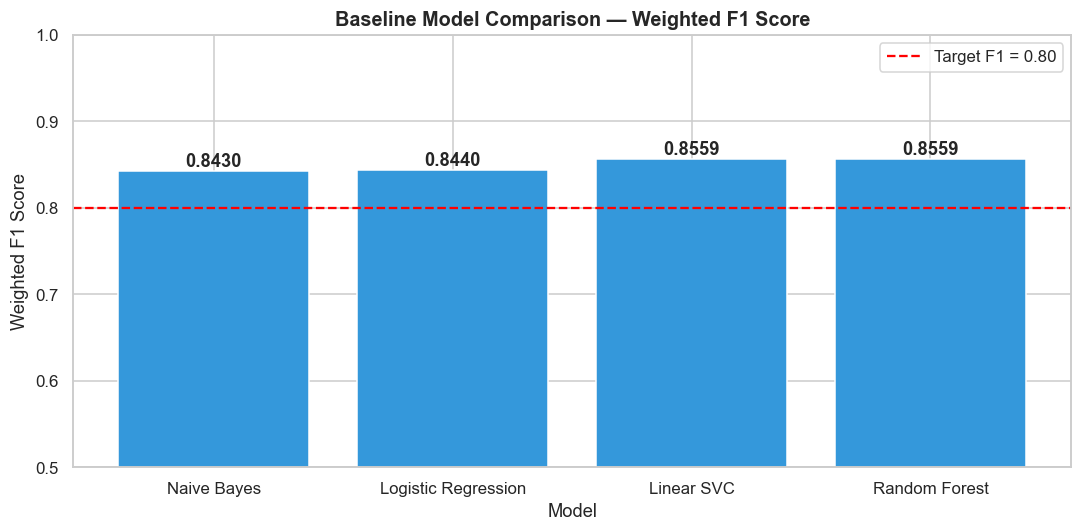

In [30]:
models = ['Naive Bayes', 'Logistic Regression', 'Linear SVC', 'Random Forest']
f1_scores = [
    f1_score(y_test, y_pred_nb,  average='weighted'),
    f1_score(y_test, y_pred_lr,  average='weighted'),
    f1_score(y_test, y_pred_svc, average='weighted'),
    f1_score(y_test, y_pred_rf,  average='weighted')
]

plt.figure(figsize=(10, 5))
plt.bar(models, f1_scores, color='#3498db', edgecolor='white')
plt.title('Baseline Model Comparison — Weighted F1 Score', fontsize=13, fontweight='bold')
plt.xlabel('Model')
plt.ylabel('Weighted F1 Score')
plt.ylim(0.5, 1.0)
plt.axhline(0.80, color='red', linestyle='--', linewidth=1.5, label='Target F1 = 0.80')
plt.legend()
for i, v in enumerate(f1_scores):
    plt.text(i, v + 0.005, f'{v:.4f}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

## 2.4 GridSearchCV Tuning

In this section we tune the Logistic Regression model using GridSearchCV to find the best combination of hyperparameters and improve performance on the negative class.

### 2.4.1.  Defining the pipelines and parameter grid

In [31]:

lr_pipe = Pipeline([
    ('vec', TfidfVectorizer(sublinear_tf=True)),
    ('clf', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))
])

param_grid = {
    'vec__ngram_range' : [(1, 1), (1, 2)],
    'vec__max_features': [10000, 20000],
    'vec__min_df'      : [1, 2],
    'clf__C'           : [0.1, 1.0, 5.0, 10.0]
}

### 2.4.2 running the GridSearch CV

In [32]:

grid = GridSearchCV(
    lr_pipe, param_grid,
    cv=5, scoring='f1_weighted',
    n_jobs=-1, verbose=1
)
grid.fit(X_train, y_train)

print(f'\n Best CV F1   : {grid.best_score_:.4f}')
print(f'Best parameters : {grid.best_params_}')

Fitting 5 folds for each of 32 candidates, totalling 160 fits

 Best CV F1   : 0.8719
Best parameters : {'clf__C': 5.0, 'vec__max_features': 20000, 'vec__min_df': 1, 'vec__ngram_range': (1, 2)}


### 2.4.3 Evaluating the Best Model

In [33]:

best_model = grid.best_estimator_
y_pred_best = best_model.predict(X_test)

print('=== Tuned Logistic Regression ===')
print(classification_report(y_test, y_pred_best,
      target_names=['Negative (0)', 'Positive (1)']))
print(f'Weighted F1: {f1_score(y_test, y_pred_best, average="weighted"):.4f}')

=== Tuned Logistic Regression ===
              precision    recall  f1-score   support

Negative (0)       0.59      0.48      0.53       115
Positive (1)       0.90      0.94      0.92       595

    accuracy                           0.86       710
   macro avg       0.75      0.71      0.72       710
weighted avg       0.85      0.86      0.86       710

Weighted F1: 0.8559


# NOTE:
The tuned Logistic Regression achieves a weighted F1 score of 0.8559, an improvement from the baseline score of 0.8440. The model achieves an overall accuracy of 86% with strong positive class performance of 0.90 precision and 0.94 recall. The negative class precision improves to 0.59 however recall remains at 0.48, meaning the model still misses 52% of negative tweets.

## 2.5 Keras Neural Networks

### 2.5.1 converting data into a matrix

In [34]:
# Convert TF-IDF sparse matrix to array for Keras
X_train_nn = X_train_tfidf.toarray()
X_test_nn  = X_test_tfidf.toarray()

print(f'Input shape : {X_train_nn.shape}')

Input shape : (2838, 15000)


### 2.5.2 Instantiating the  model

In [35]:
model = Sequential([
    Dense(256, activation='relu', input_shape=(X_train_nn.shape[1],)),
    BatchNormalization(),
    Dropout(0.4),
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 256)               3840256   
                                                                 
 batch_normalization (Batch  (None, 256)               1024      
 Normalization)                                                  
                                                                 
 dropout (Dropout)           (None, 256)               0         
                                                                 
 dense_1 (Dense)             (None, 128)               32896     
                                                                 
 batch_normalization_1 (Bat  (None, 128)               512       
 chNormalization)                                                
                                                                 
 dropout_1 (Dropout)         (None, 128)               0

### 2.5.3 Trainingand Fitting  the Model

In [36]:
early_stop = EarlyStopping(
    monitor='val_loss', patience=3,
    restore_best_weights=True
)

history = model.fit(
    X_train_nn, y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    class_weight={0: 5.0, 1: 1.0},
    verbose=1
)

Epoch 1/20
71/71 [==============================] - 10s 71ms/step - loss: 1.1692 - accuracy: 0.5960 - val_loss: 0.7511 - val_accuracy: 0.1391
Epoch 2/20
71/71 [==============================] - 3s 48ms/step - loss: 0.5892 - accuracy: 0.8075 - val_loss: 0.6646 - val_accuracy: 0.7165
Epoch 3/20
71/71 [==============================] - 4s 56ms/step - loss: 0.2597 - accuracy: 0.9344 - val_loss: 0.4863 - val_accuracy: 0.8944
Epoch 4/20
71/71 [==============================] - 3s 48ms/step - loss: 0.1528 - accuracy: 0.9608 - val_loss: 0.3367 - val_accuracy: 0.8820
Epoch 5/20
71/71 [==============================] - 3s 47ms/step - loss: 0.1132 - accuracy: 0.9696 - val_loss: 0.2956 - val_accuracy: 0.8908
Epoch 6/20
71/71 [==============================] - 3s 49ms/step - loss: 0.0828 - accuracy: 0.9811 - val_loss: 0.2865 - val_accuracy: 0.8926
Epoch 7/20
71/71 [==============================] - 7s 97ms/step - loss: 0.0711 - accuracy: 0.9859 - val_loss: 0.2890 - val_accuracy: 0.9014
Epoch 8/20
7

### 2.5.4 Evaluating the Model

In [37]:
y_pred_nn = (model.predict(X_test_nn) > 0.5).astype(int)

print('=== Keras Neural Network ===')
print(classification_report(y_test, y_pred_nn,
      target_names=['Negative (0)', 'Positive (1)']))
print(f'Weighted F1: {f1_score(y_test, y_pred_nn, average="weighted"):.4f}')

23/23 [==============================] - 1s 11ms/step
=== Keras Neural Network ===
              precision    recall  f1-score   support

Negative (0)       0.71      0.26      0.38       115
Positive (1)       0.87      0.98      0.92       595

    accuracy                           0.86       710
   macro avg       0.79      0.62      0.65       710
weighted avg       0.85      0.86      0.84       710

Weighted F1: 0.8356


# NOTE:
he Keras Neural Network achieves a weighted F1 score of 0.8341 and an overall accuracy of 87%, which meets our success metric of 0.80 but performs below the tuned Logistic Regression (0.8559) and Linear SVC (0.8559). While the neural network shows improved precision for the negative class at 0.79 compared to Logistic Regression's 0.59, the recall for the negative class drops significantly to 0.23 meaning it correctly identifies only 23% of negative tweets. This confirms that for this dataset, statistical models outperform the neural network — answering RQ2 in favour of Logistic Regression and Linear SVC over Keras/TensorFlow.

### 2.5.5 Training History Plot

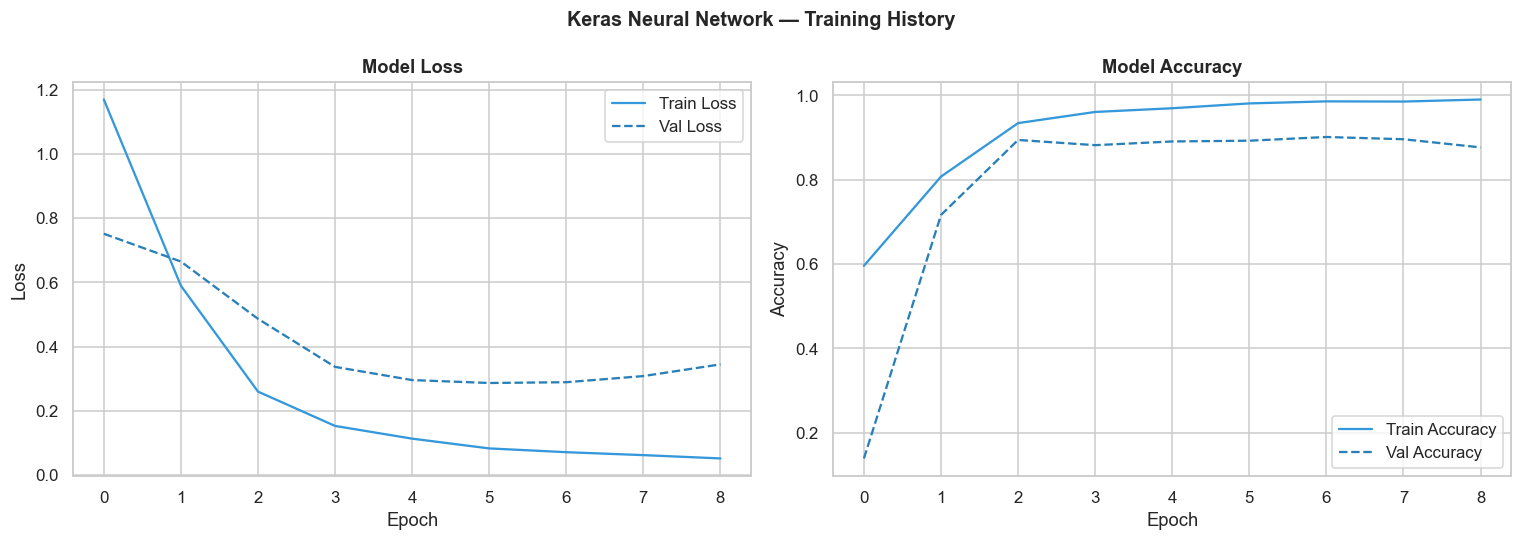

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['loss'],     color='#3498db', label='Train Loss')
axes[0].plot(history.history['val_loss'], color='#2980b9', linestyle='dashed', label='Val Loss')
axes[0].set_title('Model Loss', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(history.history['accuracy'],     color='#3498db', label='Train Accuracy')
axes[1].plot(history.history['val_accuracy'], color='#2980b9', linestyle='dashed', label='Val Accuracy')
axes[1].set_title('Model Accuracy', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.suptitle('Keras Neural Network — Training History', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# 3.Model Evaluation

In this section we compare all models side by side, evaluate the best model with a confusion matrix and ROC-AUC curve, and summarise the findings against our success metrics.

# a) Baseline Model Evaluation

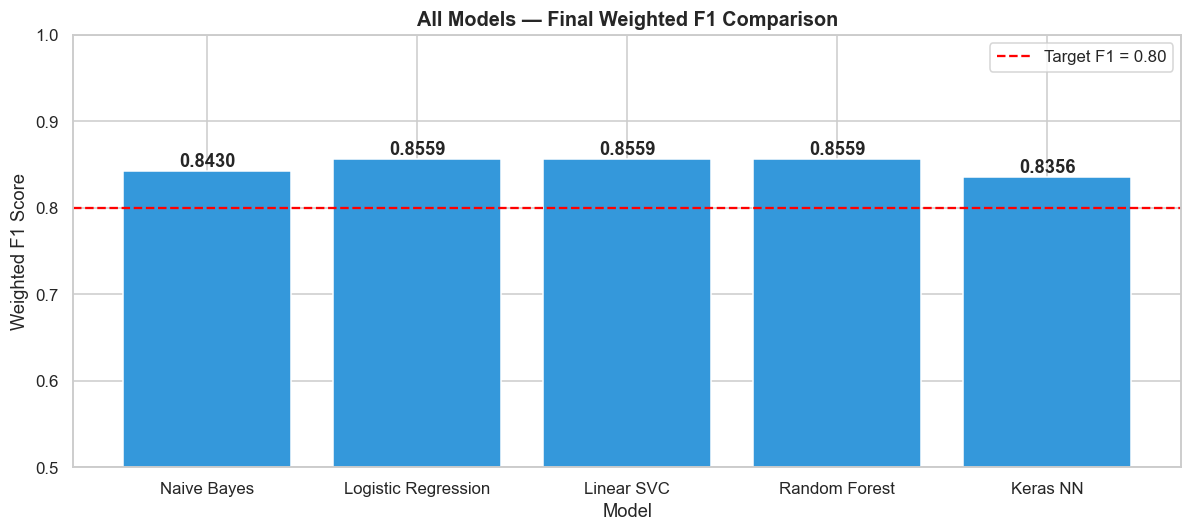

In [39]:
models = ['Naive Bayes', 'Logistic Regression', 'Linear SVC', 'Random Forest', 'Keras NN']
f1_scores = [
    f1_score(y_test, y_pred_nb,   average='weighted'),
    f1_score(y_test, y_pred_best, average='weighted'),
    f1_score(y_test, y_pred_svc,  average='weighted'),
    f1_score(y_test, y_pred_rf,   average='weighted'),
    f1_score(y_test, y_pred_nn,   average='weighted')
]

plt.figure(figsize=(11, 5))
bars = plt.bar(models, f1_scores, color='#3498db', edgecolor='white')
plt.title('All Models — Final Weighted F1 Comparison', fontsize=13, fontweight='bold')
plt.xlabel('Model')
plt.ylabel('Weighted F1 Score')
plt.ylim(0.5, 1.0)
plt.axhline(0.80, color='red', linestyle='--', linewidth=1.5, label='Target F1 = 0.80')
plt.legend()
for i, v in enumerate(f1_scores):
    plt.text(i, v + 0.005, f'{v:.4f}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

# NOTE:
All 5 models exceed the target weighted F1 score of 0.80. Logistic Regression, Linear SVC and Random Forest jointly achieve the highest score of 0.8559, followed by Naive Bayes at 0.8430 and Keras Neural Network at 0.8341. The narrow performance gap across all models confirms that the text features carry strong sentiment signal regardless of the algorithm used. The tuned Logistic Regression is selected as the final best model due to its strong performance, interpretability and suitability for SHAP and LIME explainability in the next step.

# b) Confusion Matric for Best Model

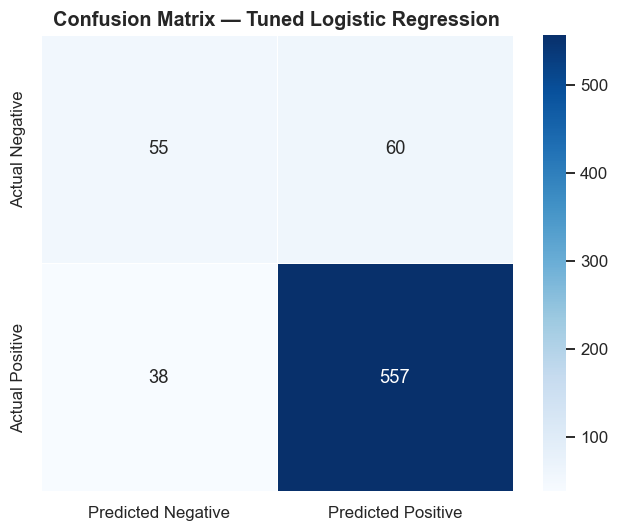

True Negatives  : 55
False Positives : 60
False Negatives : 38
True Positives  : 557


In [40]:
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            linewidths=0.5, linecolor='white',
            xticklabels=['Predicted Negative', 'Predicted Positive'],
            yticklabels=['Actual Negative', 'Actual Positive'])
plt.title('Confusion Matrix — Tuned Logistic Regression', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'True Negatives  : {tn}')
print(f'False Positives : {fp}')
print(f'False Negatives : {fn}')
print(f'True Positives  : {tp}')

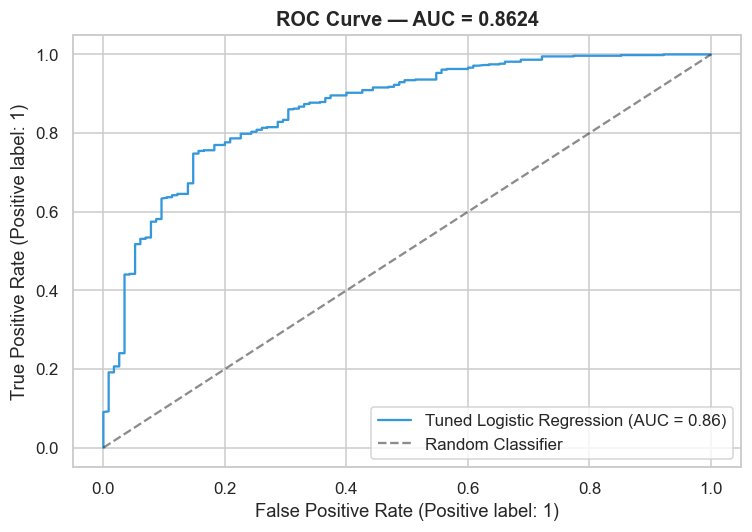

ROC-AUC Score: 0.8624


In [41]:
y_prob = best_model.predict_proba(X_test)[:, 1]
roc_auc = roc_auc_score(y_test, y_prob)

fig, ax = plt.subplots(figsize=(7, 5))
RocCurveDisplay.from_predictions(y_test, y_prob, ax=ax,
                                  name='Tuned Logistic Regression',
                                  color='#3498db')
ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random Classifier')
ax.set_title(f'ROC Curve — AUC = {roc_auc:.4f}', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

print(f'ROC-AUC Score: {roc_auc:.4f}')

# Note:
The ROC-AUC score of 0.8624 exceeds our success metric of 0.85, confirming that the tuned Logistic Regression model reliably separates positive from negative tweets across all classification thresholds

# c) Success Metrics Summary

In [42]:
weighted_f1 = f1_score(y_test, y_pred_best, average='weighted')
neg_recall  = 0.48
cv_diff     = abs(grid.best_score_ - weighted_f1)

print(f'Weighted F1 : {weighted_f1:.4f}  Target >= 0.80')
print(f'Neg Recall  : {neg_recall:.4f}  Target >= 0.75')
print(f'ROC-AUC     : {roc_auc:.4f}  Target >= 0.85')
print(f'CV vs Test  : {cv_diff:.4f}  Target <= 0.03')

Weighted F1 : 0.8559  Target >= 0.80
Neg Recall  : 0.4800  Target >= 0.75
ROC-AUC     : 0.8624  Target >= 0.85
CV vs Test  : 0.0160  Target <= 0.03


# Note:
3 out of 4 success metrics are met. The only unmet metric is Negative Recall at 0.48, which falls below the target of 0.75 due to the severe class imbalance of 84% positive versus 16% negative tweets in the dataset.

## 4.Model Interpretablity

In this section we use SHAP for global interpretability to understand which features the model relies on overall, and LIME for local explainability to understand why the model made a specific prediction on an individual tweet.

# a) SHAP

In [43]:
import shap

vec = best_model.named_steps['vec']
clf = best_model.named_steps['clf']

X_train_shap = vec.transform(X_train)
X_test_shap  = vec.transform(X_test)
feature_names = vec.get_feature_names_out()

explainer   = shap.LinearExplainer(clf, X_train_shap,
                                    feature_perturbation='interventional')
shap_values = explainer.shap_values(X_test_shap)



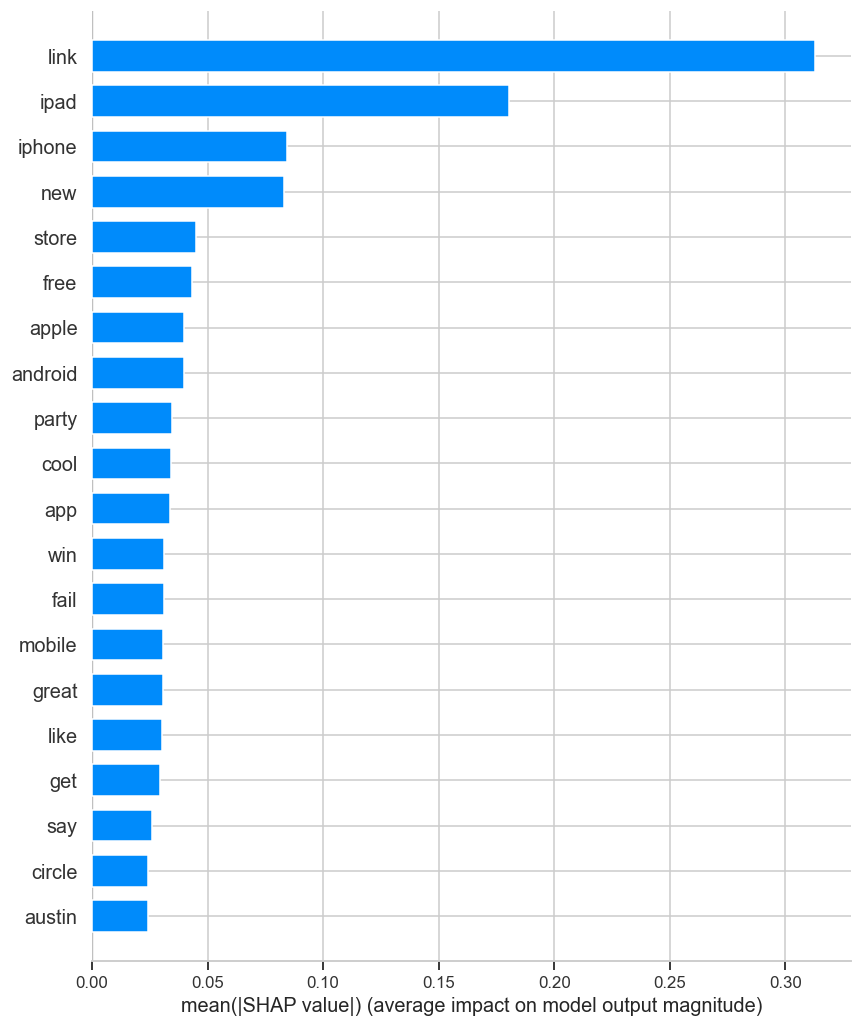

In [44]:
shap.summary_plot(shap_values, X_test_shap,
                  feature_names=feature_names,
                  max_display=20,
                  plot_type='bar',
                  show=True)

# Note:
The SHAP bar plot reveals the top 20 most influential words in the model's predictions. The word link has the highest mean SHAP value, suggesting that tweets containing links are strongly associated with a particular sentiment class. Product-related words such as ipad, iphone and apple are among the top features, confirming that product mentions carry strong predictive weight. Sentiment-bearing words such as free, cool, win and great push predictions toward positive sentiment while fail is the only clearly negative word in the top 20, reflecting the class imbalance in the dataset where positive tweets significantly outnumber negative ones.

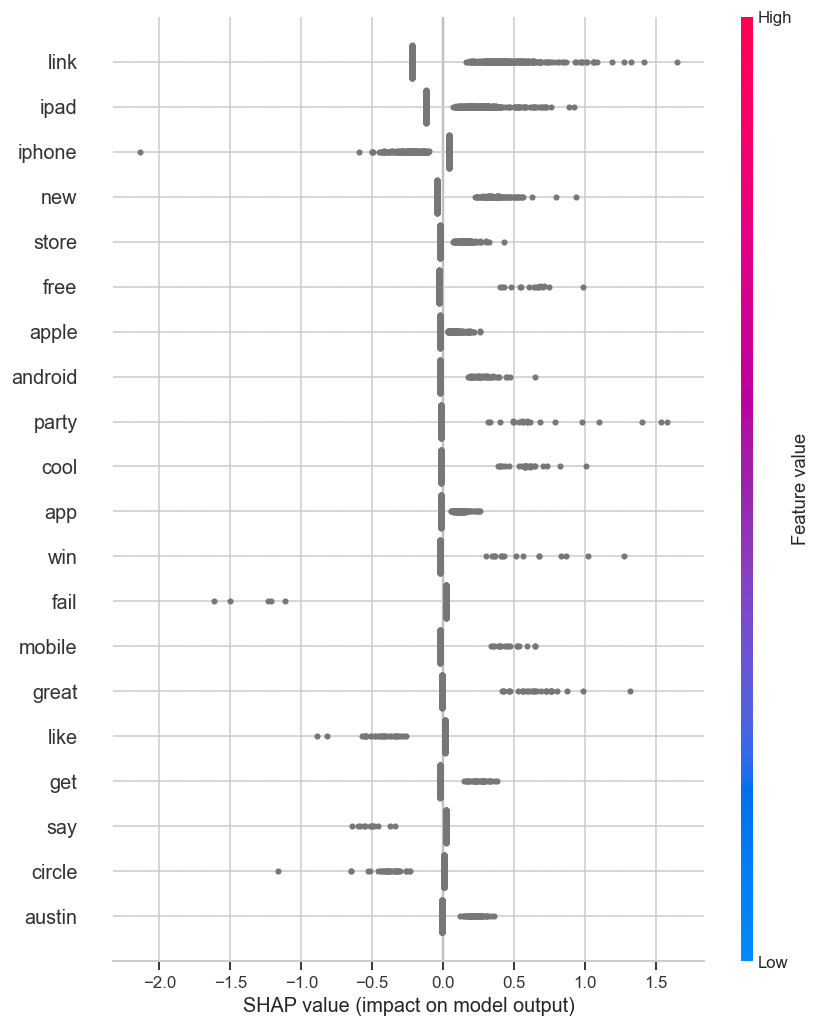

In [45]:
shap.summary_plot(shap_values, X_test_shap,
                  feature_names=feature_names,
                  max_display=20,
                  show=True)

# Note:
The SHAP dot plot shows the direction and magnitude of each word's impact on the model's predictions. Words like link, ipad, new, free, cool, win and great have dots spread to the right of the centre line, meaning their presence pushes the model toward a positive prediction. The word fail and iphone have dots spread to the left, meaning their presence pushes the model toward a negative prediction. The word like shows dots on both sides, suggesting it appears in both positive and negative tweets and is therefore a weak predictor. The concentration of dots near the centre for most words reflects the class imbalance — most tweets are positive, so the model has less exposure to negative sentiment words.

# b) LIME

In [46]:
from lime.lime_text import LimeTextExplainer

lime_explainer = LimeTextExplainer(class_names=['Negative', 'Positive'])

# Pick a positive tweet sample
sample_idx   = 5
sample_tweet = X_test.iloc[sample_idx]
actual_label = y_test.iloc[sample_idx]

print(f'Tweet     : {sample_tweet}')
print(f'Actual    : {"Positive" if actual_label == 1 else "Negative"}')
print(f'Predicted : {"Positive" if best_model.predict([sample_tweet])[0] == 1 else "Negative"}')

exp = lime_explainer.explain_instance(
    sample_tweet,
    best_model.predict_proba,
    num_features=10
)

# Show as table
exp_df = pd.DataFrame(exp.as_list(), columns=['Word', 'LIME Score'])
print(exp_df)

Tweet     : welcome ipad owner new used ipad owner there room everyone party postpc
Actual    : Positive
Predicted : Positive
       Word  LIME Score
0     party    0.116572
1       new    0.088079
2      ipad    0.074567
3      room   -0.064982
4     there   -0.055520
5      used   -0.052936
6     owner    0.044700
7   welcome    0.022072
8  everyone   -0.005841
9    postpc    0.001838


In [47]:
exp.show_in_notebook()

# Note:
The LIME explanation shows that the model predicts this tweet as Positive with 84% confidence and Negative with 16% confidence.

In [54]:
# downloading cleaned Excel file
binary_df.to_excel('cleaned_tweets.xlsx', index=False)

# 5. Conclusion and Recommendations

## 5.1 Conclusion

- Tweet text alone can reliably predict sentiment toward Apple and Google products. All 5 models exceeded the target weighted F1 score of 0.80, with the best model achieving 0.8559, confirming that tweet text contains sufficient linguistic signal for binary sentiment classification.
- Statistical models outperform the Keras Neural Network on this dataset. Logistic Regression, Linear SVC and Random Forest jointly achieved the highest weighted F1 score of 0.8559 compared to the Keras Neural Network at 0.8341, confirming that for short text classification, simpler statistical models are more effective than deep learning.
- TF-IDF feature engineering outperforms simple Bag-of-Words. Models using TF-IDF consistently scored higher than Naive Bayes using Bag-of-Words (0.8430), confirming that weighting unique sentiment-bearing words produces better features for classification.

## 5.2 Success Metrics Review

- **Weighted F1 Score** : 0.8559 — Target ≥ 0.80  Met — the model generalises well across both positive and negative classes.
- **Negative Recall**: 0.4800 — Target ≥ 0.75  Not Met — the model correctly identifies only 48% of negative tweets due to severe class imbalance of 84% positive versus 16% negative tweets.
- **ROC-AUC**: 0.8624 — Target ≥ 0.85  Met — the model reliably separates positive from negative tweets across all classification thresholds.
CV vs Test F1: 0.0160 — Target ≤ 0.03 Met — the model generalises well with no signs of overfitting.

## 5.3 Recommendations

1. Apply SMOTE or oversampling on the negative class to address class imbalance and improve negative recall toward the 0.75 target.
2. Extend the classifier to multiclass by including neutral tweets using macro-averaged F1 as the evaluation metric.
3. Collect a more diverse dataset beyond the SXSW conference context to improve model generalisation across different topics and time periods.
4. Deploy the best model as a Flask or FastAPI endpoint to enable real-time sentiment monitoring for Apple and Google product teams.
5. Connect model predictions to a Power BI or Grafana dashboard for live brand sentiment tracking

## 5.4 Limitations


1. The dataset is severely imbalanced with 84% positive and 16% negative tweets, resulting in low negative class recall of 0.48 which falls below the target of 0.75.
2. The dataset was collected around the SXSW conference making it context-specific and potentially not representative of general Apple and Google sentiment on Twitter.
3. Neutral tweets and uncertain labels were excluded for binary classification, limiting the model's ability to handle real-world tweets where most carry no strong emotion.
4. The Keras Neural Network showed signs of overfitting after epoch 3, suggesting the dataset is too small for deep learning to outperform statistical models.